# scan_driven — interactive notebook
This notebook reproduces `scripts/scan_driven.py` as runnable cells so figures appear block-by-block.
Make sure to run the cells in order. The notebook imports the repository `scripts` modules by adding the repo root to `sys.path`.

In [2]:
%matplotlib inline
import os
import sys
from pathlib import Path
# In a notebook __file__ is not defined; use the current working directory as repo root.
# This assumes you open the notebook with the repository as the working directory.
repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import correlate

print('repo_root:', repo_root)
print('python', sys.version.splitlines()[0])


repo_root: d:\github\EIB_RNN
python 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]


In [3]:
# Import functions from scripts
from scripts.relu2D_driven import make_2D_stim_with_drift, relu2D_driven, make_2D_stim_moving_dot
from scripts.relu2D_disorder import gabor2d

# --- setup parameters (same as script) ---
L = 31
time_f, space_f, drift_rate, device = 0.1*1, 2.5*2, 0.0, 'cpu'
N = L
dt = 0.0001
Nstep_init = 1 * 10 ** 3 //3
Nstep = 1 * 10 ** 3 //3
npf = 1
ntype = 'relu_gaussian'
J0 = np.array([[1, -4], [2, -2]])
K = 10 ** 2
tau = np.array([.01, .01])
u = np.array([10, 0.0])
sigma = 0.05 * np.array([1, np.sqrt(2)])

r0 = -np.linalg.inv(J0) @ u
re0 = r0[0] + 0.05 * np.random.rand(L, L)
ri0 = r0[1] + 0.08 * np.random.rand(L, L)

tt = dt * npf * np.arange(1, Nstep // npf + 1)
xx = np.arange(1, L + 1) / L
yy = np.arange(1, L + 1) / L
print('Nstep, L:', Nstep, L)

Nstep, L: 333 31


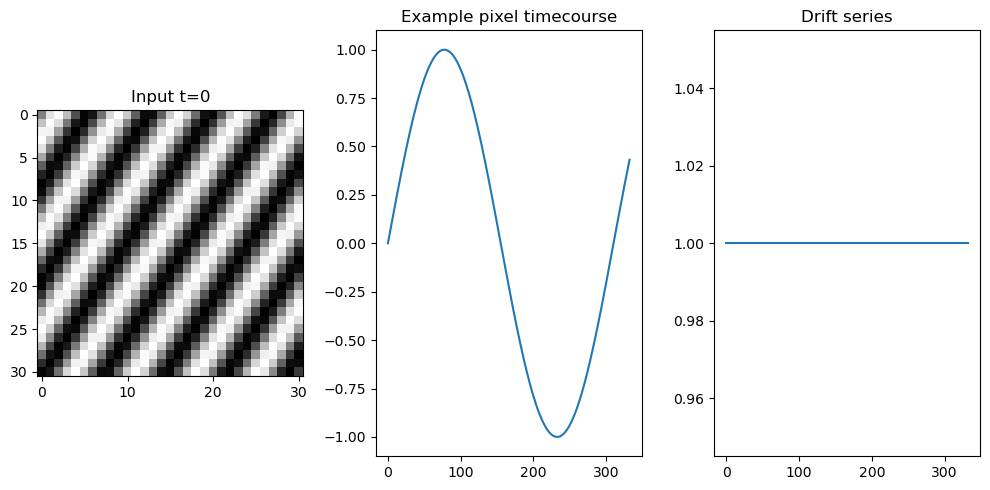

In [4]:
# --- create drifting stimulus and visualize ---
I_xyt, drift_series = make_2D_stim_with_drift(N, Nstep, time_f, space_f, drift_rate, device=device)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(I_xyt[:, :, 0].cpu().numpy(), cmap='gray')
plt.title('Input t=0')
plt.subplot(1, 3, 2)
plt.plot(I_xyt[0, 0, :].cpu().numpy())
plt.title('Example pixel timecourse')
plt.subplot(1, 3, 3)
plt.plot(drift_series.cpu().numpy())
plt.title('Drift series')
plt.tight_layout()
plt.show()

Running trial 1/1...
initializing simulation... 0.000.00600.00900.01200.01500.01800.02100.02400.02700.03000.03300.03600.03900.04200.04500.04800.05100.05400.05700.06000.06300.06600.06900.07200.07500.07800.08100.08400.08700.09000.09300.090.090.100.10510.10810.11110.11410.11710.12010.12310.12610.12910.13210.13510.13810.14110.14410.14710.15010.15310.15610.15910.16210.16510.16810.17110.17410.17710.18010.18310.18610.18910.19210.190.190.200.200.20720.21020.21320.21620.21920.22220.22520.22820.23120.23420.23720.24020.24320.24620.24920.25220.25520.25820.26120.26420.26720.27020.27320.27620.27920.28220.28520.28820.29120.29420.290.300.300.30630.30930.31230.31530.31830.32130.32430.32730.33030.33330.33630.33930.34230.34530.34830.35130.35430.35730.36030.36330.36630.36930.37230.37530.37830.38130.38430.38730.39030.39330.390.390.400.40540.40840.41140.41440.41740.42040.42340.42640.42940.43240.43540.43840.44140.44440.44740.45040.45340.45640.45940.46240.46540.46840.47140.47440.47740.48040.48340.48640.48940.

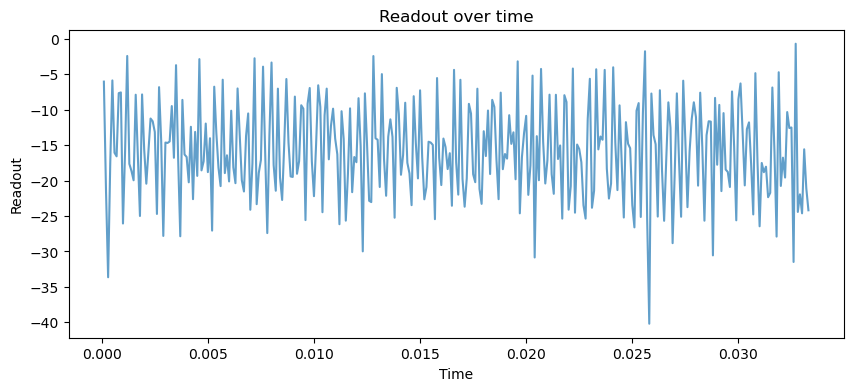

In [5]:
# --- run a single simulation trial and plot readout ---
from scripts.relu2D_driven import relu2D_driven

n_repeats = 1
w_readout = np.random.randn(L**2)
readouts = np.zeros((n_repeats, Nstep // npf))

for rr in range(n_repeats):
    print(f'Running trial {rr+1}/{n_repeats}...')
    re0 = r0[0] + 0.05 * np.random.rand(L, L)
    ri0 = r0[1] + 0.08 * np.random.rand(L, L)
    re_all, ri_all = relu2D_driven(L, dt, Nstep_init, Nstep, npf, ntype, K, tau, u, J0, sigma, I_xyt, re0, ri0)
    re_all_reshaped = re_all.reshape(Nstep // npf, L * L)
    readouts[rr, :] = re_all_reshaped @ w_readout

plt.figure(figsize=(10, 4))
for rr in range(n_repeats):
    plt.plot(tt, readouts[rr, :], alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Readout')
plt.title('Readout over time')
plt.show()

In [8]:
# --- object tracking vs K strength ---
Ks = [0.1, 1, 10, 100, 1000]
cross_corrs = []
trackings = []
I_xyt_dot = make_2D_stim_moving_dot(N, Nstep, dot_size=0.05, drift_rate=1.5, device=device)
I_xyt_dot = I_xyt_dot * 10

for K in Ks:
    print('Running simulation for K=', K)
    re_all, ri_all = relu2D_driven(L, dt, Nstep_init, Nstep, npf, ntype, K, tau, u, J0, sigma, I_xyt_dot, re0, ri0)
    re_all_reshaped = re_all.reshape(Nstep // npf, L * L)
    readout = re_all_reshaped @ w_readout
    # simple Pearson corr with drift_series
    pearson = np.corrcoef(readout, drift_series.cpu().numpy())[0, 1]
    print('pearson:', pearson)

    # compute COM for input and response
    y_coords = torch.linspace(0, 1, N, device=device, dtype=I_xyt_dot.dtype).view(1, N, 1)
    num_input = (I_xyt_dot * y_coords).sum(dim=(0,1))
    den_input = I_xyt_dot.sum(dim=(0,1))
    com_input = num_input / (den_input + 1e-8)

    re_all_t = torch.tensor(re_all, device=device, dtype=torch.float32)
    num_re = (re_all_t * y_coords).sum(dim=(0,1))
    den_re = re_all_t.sum(dim=(0,1))
    com_re = num_re / (den_re + 1e-8)

    eps = 1e-8
    com_input_n = 2 * (com_input - com_input.min()) / (com_input.max() - com_input.min() + eps) - 1
    com_re_n = 2 * (com_re - com_re.min()) / (com_re.max() - com_re.min() + eps) - 1

    trackings.append(com_re_n.detach().cpu().numpy())

    x = com_input_n.detach().cpu().numpy().astype(float)
    y = com_re_n.detach().cpu().numpy().astype(float)
    x0 = x - x.mean()
    y0 = y - y.mean()
    raw_corr = correlate(x0, y0, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    overlap = len(x) - np.abs(lags)
    corr_unbiased = raw_corr / overlap
    print('lags shape', lags.shape, 'corr_unbiased', corr_unbiased.shape)
    cross_corrs.append(corr_unbiased)

print('done loop')

Running simulation for K= 0.1
initializing simulation... 0.000.00600.00901

0.01200.01500.01800.02100.02400.02700.03000.03300.03600.03900.04200.04500.04800.05100.05400.05700.06000.06300.06600.06900.07200.07500.07800.08100.08400.08700.09000.09300.090.090.100.10510.10810.11110.11410.11710.12010.12310.12610.12910.13210.13510.13810.14110.14410.14710.15010.15310.15610.15910.16210.16510.16810.17110.17410.17710.18010.18310.18610.18910.19210.190.190.200.200.20720.21020.21320.21620.21920.22220.22520.22820.23120.23420.23720.24020.24320.24620.24920.25220.25520.25820.26120.26420.26720.27020.27320.27620.27920.28220.28520.28820.29120.29420.290.300.300.30630.30930.31230.31530.31830.32130.32430.32730.33030.33330.33630.33930.34230.34530.34830.35130.35430.35730.36030.36330.36630.36930.37230.37530.37830.38130.38430.38730.39030.39330.390.390.400.40540.40840.41140.41440.41740.42040.42340.42640.42940.43240.43540.43840.44140.44440.44740.45040.45340.45640.45940.46240.46540.46840.47140.47440.47740.48040.48340.48640.48940.49240.490.490.500.500.50750.51050.51350.51650.51950.52250.52550

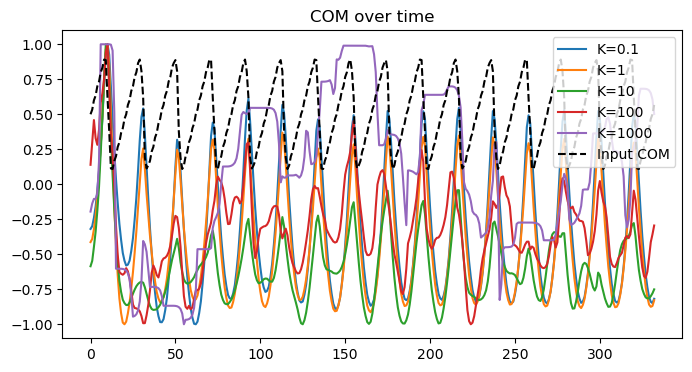

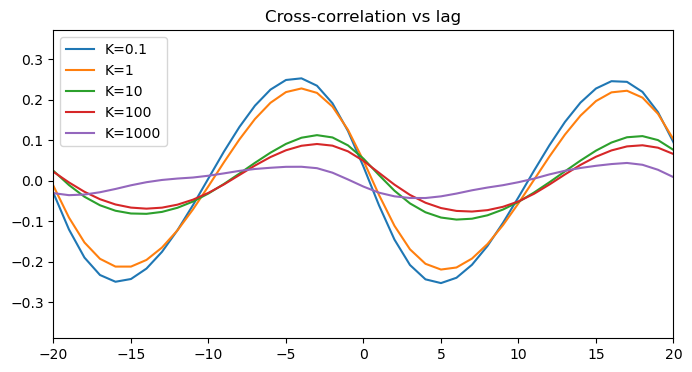

In [9]:
# --- plot tracking and cross-correlation ---
plt.figure(figsize=(8, 4))
for idx, tr in enumerate(trackings):
    plt.plot(tr, label=f'K={Ks[idx]}')
plt.plot(com_input.detach().cpu().numpy(), label='Input COM', color='k', linestyle='--')
plt.legend()
plt.title('COM over time')
plt.show()

plt.figure(figsize=(8, 4))
for idx, cc in enumerate(cross_corrs):
    plt.plot(lags, cc, label=f'K={Ks[idx]}')
plt.xlim([-20, 20])
plt.legend()
plt.title('Cross-correlation vs lag')
plt.show()